# 07_Sampling

### What is Sampling?

Sampling is the process of selecting a subset of individuals or observations from a larger population to estimate characteristics of the whole population without examining every member.

Simply put, it lets us draw conclusions about a large group by studying only a smaller, manageable part of it.

Topics covered: Sampling, Random Sampling, Stratified Sampling, Cluster Sampling, Systematic Sampling, Sampling Bias, Sampling Error, Sample Size.

## 01. Sampling

**Definition**: Sampling is the process of selecting a subset of individuals or observations from a larger population to estimate characteristics of the whole population without examining every member.

**Formula**: Sampling fraction f = n / N, where n = sample size, N = population size

**Where it is used**: Used whenever studying an entire population is impractical, costly, or impossible — surveys, quality control, medical trials, ML dataset creation.

**Real-World Example**: A pollster surveys 1,000 voters out of millions to predict election results.

**AI/ML Example**: Train/test/validation splits are a form of sampling from the full dataset to build and evaluate models efficiently.

In [1]:
import numpy as np

population = np.arange(1, 10001)
sample = np.random.choice(population, size=100, replace=False)
print("Population size:", len(population))
print("Sample size:", len(sample))
print("Sample mean:", np.mean(sample))

Population size: 10000
Sample size: 100
Sample mean: 5290.97


**Interpretation**: The sample mean (~5000) closely approximates the population mean, showing that a well-chosen subset can represent the whole population.

## 02. Random Sampling

**Definition**: Random Sampling (Simple Random Sampling) gives every member of the population an equal chance of being selected, minimizing selection bias.

**Formula**: P(selecting any unit) = 1 / N

**Where it is used**: Used in experiments and surveys where an unbiased, representative sample is required.

**Real-World Example**: Drawing names from a lottery drum to select winners.

**AI/ML Example**: Randomly shuffling and sampling rows from a dataset before splitting into train/test sets to avoid ordering bias.

In [2]:
import numpy as np

population = np.arange(1, 1001)
sample = np.random.choice(population, size=50, replace=False)
print("Sample:", sample[:10])
print("Sample mean:", np.mean(sample))
print("Population mean:", np.mean(population))

Sample: [ 18 884 260 558 959 623 444 638 855 110]
Sample mean: 491.2
Population mean: 500.5


**Interpretation**: The sample mean is close to the true population mean, confirming that random sampling produces an unbiased estimate.

## 03. Stratified Sampling

**Definition**: Stratified Sampling divides the population into homogeneous subgroups (strata) based on a shared characteristic, then samples proportionally from each stratum.

**Formula**: n_h = (N_h / N) × n, where N_h = size of stratum h, N = total population, n = total sample size

**Where it is used**: Used when subgroups differ significantly and each must be fairly represented — market research across age groups, medical studies across disease severity levels.

**Real-World Example**: A university surveys students by sampling proportionally from each department (Engineering, Arts, Science) rather than the whole student body randomly.

**AI/ML Example**: Stratified train-test splitting (e.g., `train_test_split(..., stratify=y)`) ensures each class in an imbalanced classification dataset is proportionally represented in both sets.

In [3]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'id': range(1, 1001),
    'group': np.random.choice(['A', 'B', 'C'], size=1000, p=[0.5, 0.3, 0.2])
})
sample = pd.concat([g.sample(frac=0.1) for _, g in df.groupby('group')])
print(df['group'].value_counts(normalize=True))
print(sample['group'].value_counts(normalize=True))

group
A    0.535
B    0.287
C    0.178
Name: proportion, dtype: float64
group
A    0.534653
B    0.287129
C    0.178218
Name: proportion, dtype: float64


**Interpretation**: The group proportions in the sample closely match the group proportions in the full population, confirming each stratum is fairly represented.

## 04. Cluster Sampling

**Definition**: Cluster Sampling divides the population into naturally occurring groups (clusters), randomly selects a few whole clusters, and includes all (or a random subset of) members within those clusters.

**Formula**: Sample = Σ (all units in selected clusters), where clusters are selected from k total clusters using simple random sampling

**Where it is used**: Used when the population is geographically or naturally grouped and a full sampling frame of individuals is unavailable or costly — national surveys, epidemiological studies.

**Real-World Example**: To survey households in a city, researchers randomly pick 20 neighborhoods (clusters) and interview every household within those neighborhoods.

**AI/ML Example**: In federated learning, data naturally clusters by device/user; a central model may sample a subset of devices (clusters) per training round instead of individual data points.

In [4]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'id': range(1, 1001),
    'cluster': np.repeat(range(1, 21), 50)
})
selected_clusters = np.random.choice(df['cluster'].unique(), size=4, replace=False)
sample = df[df['cluster'].isin(selected_clusters)]
print("Selected clusters:", selected_clusters)
print("Sample size:", len(sample))

Selected clusters: [ 2 13 19 18]
Sample size: 200


**Interpretation**: All members from the 4 randomly chosen clusters (200 records) form the sample, showing how cluster sampling collects data in whole groups rather than scattered individuals.

## 05. Systematic Sampling

**Definition**: Systematic Sampling selects every k-th element from a population list after a random starting point, where k is the sampling interval.

**Formula**: k = N / n, where N = population size, n = desired sample size

**Where it is used**: Used when the population is ordered in a list and a quick, evenly spread sample is needed — quality control on production lines, auditing records.

**Real-World Example**: A factory inspector checks every 10th item coming off the assembly line for defects.

**AI/ML Example**: Selecting every n-th frame from a video stream to build a training dataset for a computer vision model without processing every frame.

In [5]:
import numpy as np

population = np.arange(1, 1001)
k = 10
start = np.random.randint(0, k)
sample = population[start::k]
print("Interval k:", k)
print("Sample size:", len(sample))
print("Sample:", sample[:10])

Interval k: 10
Sample size: 100
Sample: [ 4 14 24 34 44 54 64 74 84 94]


**Interpretation**: The sample consists of evenly spaced elements across the population, giving good coverage of the entire range with minimal computation.

## 06. Sampling Bias

**Definition**: Sampling Bias occurs when some members of the population are systematically more or less likely to be included than others, making the sample unrepresentative.

**Formula**: No single formula — bias is measured as Bias = E[sample statistic] − true population parameter

**Where it is used**: A concept applied to detect and correct flawed data collection in surveys, experiments, and ML datasets.

**Real-World Example**: A phone survey conducted only during work hours oversamples unemployed or retired people, undersampling working adults.

**AI/ML Example**: A facial recognition model trained mostly on images of one demographic performs poorly on underrepresented groups due to biased training data collection.

In [6]:
import numpy as np

population = np.concatenate([np.random.normal(50, 5, 900), np.random.normal(90, 5, 100)])
biased_sample = population[population > 70]
unbiased_sample = np.random.choice(population, size=100, replace=False)
print("Population mean:", np.mean(population))
print("Biased sample mean:", np.mean(biased_sample))
print("Unbiased sample mean:", np.mean(unbiased_sample))

Population mean: 54.046715876357226
Biased sample mean: 89.93197024468942
Unbiased sample mean: 55.33485984555594


**Interpretation**: The biased sample mean is far higher than the true population mean, while the unbiased random sample stays close to it — illustrating how skewed selection distorts conclusions.

## 07. Sampling Error

**Definition**: Sampling Error is the natural difference between a sample statistic (e.g., sample mean) and the true population parameter, arising simply because a sample is not the full population.

**Formula**: Standard Error (SE) = σ / √n, where σ = population standard deviation, n = sample size

**Where it is used**: Used to quantify the precision of estimates in surveys, confidence intervals, and hypothesis testing.

**Real-World Example**: Two different random samples of 500 voters from the same population give slightly different election prediction percentages purely due to chance.

**AI/ML Example**: Cross-validation scores vary slightly across folds because each fold is a different sample of the data, reflecting inherent sampling error in performance estimates.

In [7]:
import numpy as np

population = np.random.normal(100, 15, 100000)
sample_means = [np.mean(np.random.choice(population, size=50, replace=False)) for _ in range(1000)]
print("Population mean:", np.mean(population))
print("Average sample mean:", np.mean(sample_means))
print("Standard Error (empirical):", np.std(sample_means))
print("Standard Error (formula):", np.std(population)/np.sqrt(50))

Population mean: 99.99227622772176
Average sample mean: 99.95195696015091
Standard Error (empirical): 2.1111156934838773
Standard Error (formula): 2.120984063556607


**Interpretation**: The empirical standard error from repeated sampling closely matches the theoretical formula σ/√n, confirming that sampling error shrinks predictably as sample size grows.

## 08. Sample Size

**Definition**: Sample Size is the number of observations selected from a population, chosen large enough to achieve a desired level of confidence and precision in the estimate.

**Formula**: n = (Z² × p × (1−p)) / E², where Z = Z-score for confidence level, p = expected proportion, E = margin of error

**Where it is used**: Used to plan surveys and experiments so results are statistically reliable without wasting resources on oversampling.

**Real-World Example**: A company determines it needs 384 survey responses for a 95% confidence level with a 5% margin of error before launching a customer satisfaction survey.

**AI/ML Example**: Determining the minimum labeled dataset size needed to train a model with a statistically reliable accuracy estimate, balancing data collection cost against precision.

In [8]:
import math

Z = 1.96
p = 0.5
E = 0.05
n = (Z**2 * p * (1-p)) / E**2
print("Required sample size:", math.ceil(n))

Required sample size: 385


**Interpretation**: A sample size of about 385 is required for a 95% confidence level with a 5% margin of error, showing how tighter precision or higher confidence demands larger samples.

## Visualization 1 — Stratified Sampling (Population vs Sample Proportions)

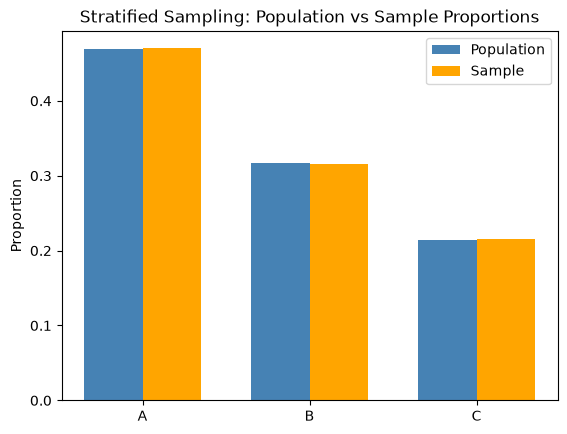

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'id': range(1, 1001),
    'group': np.random.choice(['A', 'B', 'C'], size=1000, p=[0.5, 0.3, 0.2])
})
sample = pd.concat([g.sample(frac=0.2) for _, g in df.groupby('group')])

pop_prop = df['group'].value_counts(normalize=True).sort_index()
sample_prop = sample['group'].value_counts(normalize=True).sort_index()

x = np.arange(len(pop_prop))
width = 0.35

plt.bar(x - width/2, pop_prop, width, label='Population', color='steelblue')
plt.bar(x + width/2, sample_prop, width, label='Sample', color='orange')
plt.xticks(x, pop_prop.index)
plt.ylabel("Proportion")
plt.title("Stratified Sampling: Population vs Sample Proportions")
plt.legend()
plt.show()

**Interpretation**: The bars for each group are nearly equal in height between population and sample, confirming stratified sampling preserves the original group proportions.

## Visualization 2 — Sampling Error (Distribution of Sample Means)

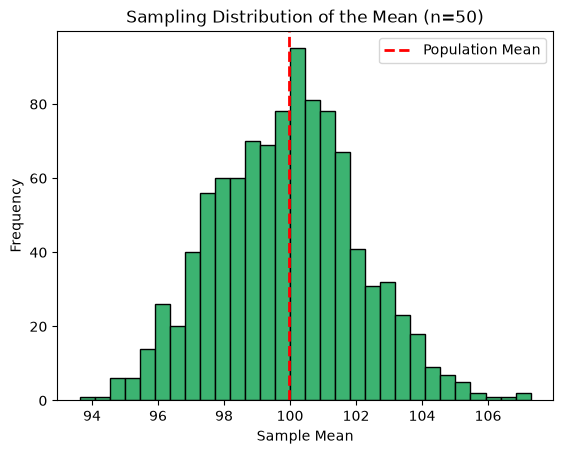

In [10]:
import numpy as np
import matplotlib.pyplot as plt

population = np.random.normal(100, 15, 100000)
sample_means = [np.mean(np.random.choice(population, size=50, replace=False)) for _ in range(1000)]

plt.hist(sample_means, bins=30, color='mediumseagreen', edgecolor='black')
plt.axvline(np.mean(population), color='red', linestyle='dashed', linewidth=2, label='Population Mean')
plt.title("Sampling Distribution of the Mean (n=50)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**Interpretation**: The sample means cluster tightly around the true population mean in a bell shape, visually demonstrating the Central Limit Theorem and the concept of sampling error.

## Overall Advantages

- Reduces cost, time, and effort compared to studying an entire population
- Enables statistical inference about large or inaccessible populations
- Different sampling designs (stratified, cluster, systematic) can be tailored to population structure for better accuracy or convenience
- Forms the foundation of train/test splits, cross-validation, and data collection pipelines in ML

## Overall Limitations

- Any sample carries inherent sampling error — results are estimates, not exact truths
- Poorly designed sampling (bias) can produce misleading conclusions regardless of sample size
- Stratified and cluster sampling require prior knowledge of population structure, which isn't always available
- Small sample sizes can lead to unreliable, high-variance estimates; determining the "right" size requires assumptions about variability

## Interview Questions
1. Population vs Sample?
Population = entire group under study. Sample = smaller subset drawn from it. We sample because studying the whole population is costly, slow, or impossible; a good sample still gives reliable estimates.

2. Stratified vs Cluster sampling?
Stratified = split into subgroups (strata), sample from every subgroup — used when subgroups differ and individual data is available. Cluster = split into groups (clusters), randomly pick a few whole clusters — used when population is spread out and individual sampling is impractical.

3. Sampling bias effect on ML models?
Sampling bias = some population members over/under-represented → unrepresentative data. In ML, biased training data leads to skewed learning, poor generalization, and unfair predictions for underrepresented groups.

4. Sampling error vs non-sampling error?
Sampling error = natural gap between sample statistic and true value, purely due to using a sample; shrinks as sample size grows. Non-sampling error = mistakes in data collection (measurement, entry, bias); doesn't shrink with larger samples.

5. CLT and sampling error link?
CLT: sample means approach a normal distribution around the true population mean as n increases. This explains why sampling error (spread of sample means) shrinks predictably as SE = σ/√n.

6. Determining sample size?
Use Cochran's formula: n = (Z² × p × (1−p)) / E². Z = confidence level score, p = expected proportion (0.5 if unknown), E = margin of error.

7. Why stratified split in train_test_split for imbalanced data?
Ensures each class appears in train/test sets in the same proportion as original data, preventing minority class underrepresentation and giving more reliable training and evaluation.

## Self-Reflection

Working through sampling reinforced that the quality of any downstream analysis or model is only as good as the data collection process behind it — a large but biased sample can be far more misleading than a small, well-designed one. Understanding the trade-offs between random, stratified, cluster, and systematic sampling helps in choosing the right strategy based on population structure, cost, and required precision. It also clarified how core ML practices like train/test splitting and cross-validation are direct applications of classical sampling theory, and how sampling error and sample size calculations connect statistics to practical decisions about how much data is "enough."
